# Work flow
----------------------------------------------------------------------
## 1. Generate spike trains
## 2. Generate calcium dynamic from spike trains with multiple noise level
## 3. Perform spike deconvolution and compare the result with original spike trains
----------------------------------------------------------------------

# Import

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from oasis.functions import gen_data, gen_sinusoidal_data, deconvolve, estimate_parameters
from oasis.plotting import simpleaxis
from oasis.oasis_methods import oasisAR1, oasisAR2
from suite2p.extraction import dcnv
from sklearn.preprocessing import MinMaxScaler
from scipy.signal import find_peaks
from scipy import stats
from scipy.ndimage import gaussian_filter1d
import os
import glob
import h5py
import warnings
warnings.simplefilter('ignore')

# Simulation

In [5]:
def calc_dF_F(F, sf_imaging, win_baseline=20):
    from scipy.ndimage import percentile_filter
    #calculate baseline
    Fbase = percentile_filter(F, percentile=8, size=int(win_baseline*sf_imaging), axes=1)
    #calculate dF/F
    Fcorr = F-Fbase
    dF_F = Fcorr/Fbase
    return Fcorr, dF_F

In [6]:
import numpy as np
from scipy.linalg import cholesky, cho_solve, cho_factor

def generate_gp_in_chunks(total_time_points, chunk_size, sigma_f, sigma_n, l):
    # Define jitter for numerical stability
    jitter = 1e-10
    
    # Squared exponential kernel function
    def squared_exponential_kernel(t1, t2, sigma_f, l, noise=0):
        """
        Compute the squared exponential covariance matrix between two arrays of time points.
        """
        t1 = t1[:, np.newaxis]
        t2 = t2[np.newaxis, :]
        sqdist = np.subtract(t1, t2) ** 2
        return sigma_f ** 2 * np.exp(-0.5 * sqdist / l ** 2) + noise * np.eye(len(t1))

    # Initialize the GP with the first chunk
    time_points = np.arange(chunk_size)
    K_init = squared_exponential_kernel(time_points, time_points, sigma_f, l, sigma_n)
    L_init = cholesky(K_init, lower=True)
    Z_init = L_init @ np.random.normal(size=(chunk_size,))
    gp = np.empty(total_time_points)
    gp[:chunk_size] = Z_init
    
    # Generate subsequent chunks
    for start in range(chunk_size, total_time_points, chunk_size):
        end = min(start + chunk_size, total_time_points)
        prev_time_points = np.arange(start - chunk_size, start)
        new_time_points = np.arange(start, end)
        
        # Compute covariance matrices
        K_prev = squared_exponential_kernel(prev_time_points, prev_time_points, sigma_f, l, sigma_n)
        K_cross = squared_exponential_kernel(prev_time_points, new_time_points, sigma_f, l)
        K_new = squared_exponential_kernel(new_time_points, new_time_points, sigma_f, l, sigma_n)
        
        # Compute conditional mean and covariance for the new chunk
        L_prev = cho_factor(K_prev, lower=True)
        mu_new = K_cross.T @ cho_solve(L_prev, gp[start - chunk_size:start])
        Sigma_new = K_new - K_cross.T @ cho_solve(L_prev, K_cross)
        
        # Add jitter for numerical stability
        Sigma_new += np.eye(Sigma_new.shape[0]) * jitter
        
        # Sample from the conditional distribution
        L_new = cholesky(Sigma_new, lower=True)
        Z_new = mu_new + L_new @ np.random.normal(size=(end - start))
        gp[start:end] = Z_new
        
    return gp

In [7]:
# def generate_gaussian_loading_matrix(q, p, scale=1.0):
#     """
#     q: ニューロン数
#     p: 潜在変数の数
#     scale: ローディングマトリックスのスケール
#     """
#     # 共分散行列の生成
#     cov_matrix = scale * (np.random.rand(p, p) - 0.5)
#     cov_matrix = cov_matrix @ cov_matrix.T  # 対称行列に変換

#     # ローディングマトリックスの生成
#     W = np.random.multivariate_normal(mean=np.zeros(p), cov=cov_matrix, size=q)
#     return W
    
def generate_random_loading_matrix(q, p, scale=1.0):
    """
    q: ニューロン数
    p: 潜在変数の数
    scale: ローディングマトリックスのスケール
    """
    return np.random.normal(loc=0.0, scale=scale, size=(q, p))


def compute_firing_rates(W, z_t, mu):
    """
    W: ローディングマトリックス
    z_t: 潜在変数の時系列
    mu: 定数オフセット
    """
    firing_rates = np.log(1 + np.exp(W @ z_t))/5
    firing_rates[np.where(firing_rates<0)[0]]=0
    return firing_rates

In [8]:
def ihpoissprocess(firing_rates, sf_ephys):
    """
    Generate spike times according to an inhomogeneous Poisson process for multiple neurons.
    
    Parameters:
    - firing_rates: 2D array of time-varying firing rates with shape (N, Times)
                    where N is the number of neurons and Times is the number of time points.
    - sf_ephys: Sampling frequency of spiking activity (Hz)
    
    Returns:
    - spkTrain: 2D array of spike trains generated from an inhomogeneous Poisson process
                with shape (N, Times).
    """
    N, Times = firing_rates.shape
    spkTrain = np.zeros((N, Times), dtype=int)
    
    for neuron_idx in range(N):
        fr_max = np.max(firing_rates[neuron_idx])
        
        # Get homogeneous spike times
        n_spike = np.random.poisson(fr_max * Times / sf_ephys)
        spk_time = np.sort(np.round(Times * np.random.rand(n_spike)))
        
        # Calculate the time step based on sampling frequency
        time_step = 1000 / sf_ephys  # in milliseconds
        t_vec = np.arange(0, Times * time_step, time_step)
        
        # Bin spike times into appropriate bins based on sampling frequency
        neuron_spk_train, _ = np.histogram(spk_time * time_step, bins=np.append(t_vec, Times * time_step))
        
        # Remove spikes from homogeneous spike times to get inhomogeneous
        U = np.random.rand(neuron_spk_train.size)
        kept_prob = firing_rates[neuron_idx] / fr_max
        neuron_spk_train[U > kept_prob] = 0
        
        spkTrain[neuron_idx] = neuron_spk_train
    spkTrain[spkTrain>1]=1
    
    return spkTrain.astype('float')

In [9]:
def simulate_calcium_dynamics(spike_train, duration, sf_ephys=1000, sf_imaging=15.2, tau_rise=0.2, tau_decay=1.0, A=1, Ca_rest=1000, sigma=0.1, eta=0.01):
    """
    Simulate calcium dynamics with noise based on spike times.
    
    Parameters:
    - spike_train: array of binary spikes (N x Time).
    - duration: duration of the simulation in seconds.
    - sf_imaging: sampling frequency of calcium signal.
    - tau_rise: rise time constant of the calcium signal.
    - tau_decay: decay time constant of the calcium signal.
    - A: amplitude of calcium increase per spike.
    - Ca_rest: resting calcium concentration.
    - sigma: standard deviation of the measurement noise.
    - eta: scale of the evolution noise.
    
    Returns:
    - t: array of time points.
    - Ca: array of noisy calcium concentrations over time.
    """
    
    dt = 1 / sf_imaging
    t_imaging = np.arange(0, duration, dt)
    
    # Simulate the spikes and calcium concentration
    N_neuron=spike_train.shape[0]
    Ca_traces=[]
    for i in range(N_neuron):
        spike_times=np.where(spike_train[i]==1)[0]/sf_ephys
        Ca = np.zeros_like(t_imaging) + Ca_rest
        for spike_time in spike_times:
            spike_idx = int(spike_time / dt)
            t_since_spike = t_imaging[spike_idx:] - t_imaging[spike_idx]
            Ca[spike_idx:] += A *Ca_rest* (np.exp(-t_since_spike / tau_decay) - np.exp(-t_since_spike / tau_rise))
        Ca[Ca<0]=0
        # Add measurement noise
        measurement_noise = np.random.normal(0, sigma * Ca_rest, size=len(t_imaging))
        Ca = Ca + measurement_noise
        Ca_traces.append(Ca)
    
    # Add evolution noise using Brownian motion
    np.random.seed(0)
    B = np.zeros_like(t_imaging)  # Drifting baseline B(t)
    dW = np.random.normal(0, np.sqrt(dt) * eta * Ca_rest, size=len(t_imaging))
    B += np.cumsum(dW)  # Integrate the Brownian motion over time
    B = np.tile(B, (N_neuron,1))
    # Combine the calcium signal with noise
    Ca_traces = Ca_traces + B
    return t_imaging, Ca_traces


In [71]:
sf_ephys=1000
total_duration = 100
total_time_points = sf_ephys*total_duration  # Total number of time points
t_ephys=np.arange(0, total_time_points, 1)/sf_ephys
chunk_size = 1000  # Number of time points in each chunk
sigma_f = 1.0  # Signal variance parameter
sigma_n = 1e-9  # Noise variance parameter
l = 5*sf_ephys  # Length-scale parameter
num_gp=5
gp=np.zeros([num_gp, total_time_points])
for i in range(num_gp):
    gp[i]=generate_gp_in_chunks(total_time_points, chunk_size, sigma_f, sigma_n, l)

In [72]:
N_neuron=500
scale=1
W = generate_random_loading_matrix(N_neuron, num_gp, scale)
mu = np.zeros((N_neuron, 1)) 
# mu = np.random.normal(loc=0.0, scale=scale, size=(N_neuron, 1))

In [73]:
firing_rates = compute_firing_rates(W, gp, mu)

In [74]:
spike_train = ihpoissprocess(firing_rates, sf_ephys)

In [75]:
firing_rate = np.sum(spike_train, axis=1)/total_duration

Text(0.5, 0, 'firing rate (Hz)')

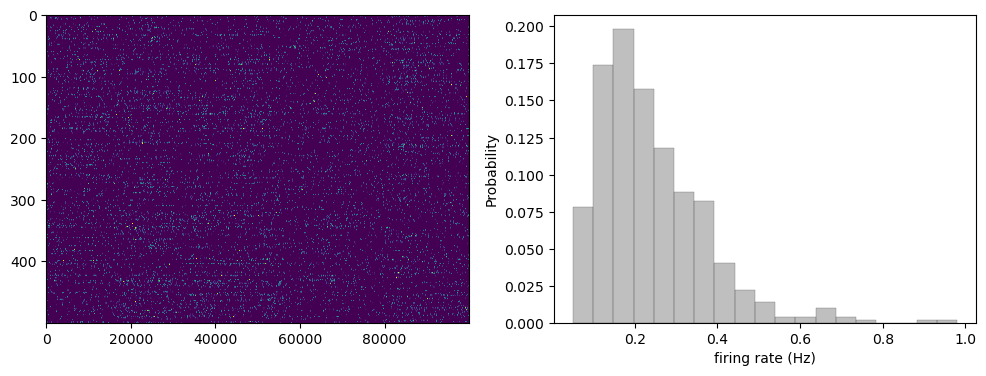

In [76]:
plt.figure(figsize=(12,4))
plt.subplot(121)
plt.imshow(spike_train, aspect='auto', vmin=0, vmax=0.01)
plt.subplot(122)
sns.histplot(firing_rate, binwidth=0.05, stat='probability', kde=False, color='gray', alpha=.5, linewidth=0.2, edgecolor='.3');
plt.xlabel('firing rate (Hz)')

In [77]:
# Generate calcium dynamics based on spike trains with different sigmas
sf_imaging=30
sigmas = [0,0.1,0.2,0.3]
# sigmas = [0, 0.05, 0.1, 0.2, 0.3]
Ca_dynamics_all = {}
pure_Ca_dynamics_all = {}
for v in sigmas:
    t_imaging, Ca_dynamics = simulate_calcium_dynamics(spike_train, duration=total_duration, sf_ephys=sf_ephys, sf_imaging=sf_imaging, tau_rise=0.002,
                                                          tau_decay=0.3, A=0.76, Ca_rest=10, sigma=v, eta=0.02)
    Ca_dynamics_all.update({v:Ca_dynamics})

In [78]:
Fcorr_sim_all={} # baseline corrected F value
dF_F_sim_all={} # baseline corrected dF/F0 value
for i in Ca_dynamics_all.keys():
    Fcorr_sim, dF_F_sim=calc_dF_F(Ca_dynamics_all[i], sf_imaging, win_baseline=30)
    Fcorr_sim_all.update({i:Fcorr_sim})
    dF_F_sim_all.update({i:dF_F_sim})

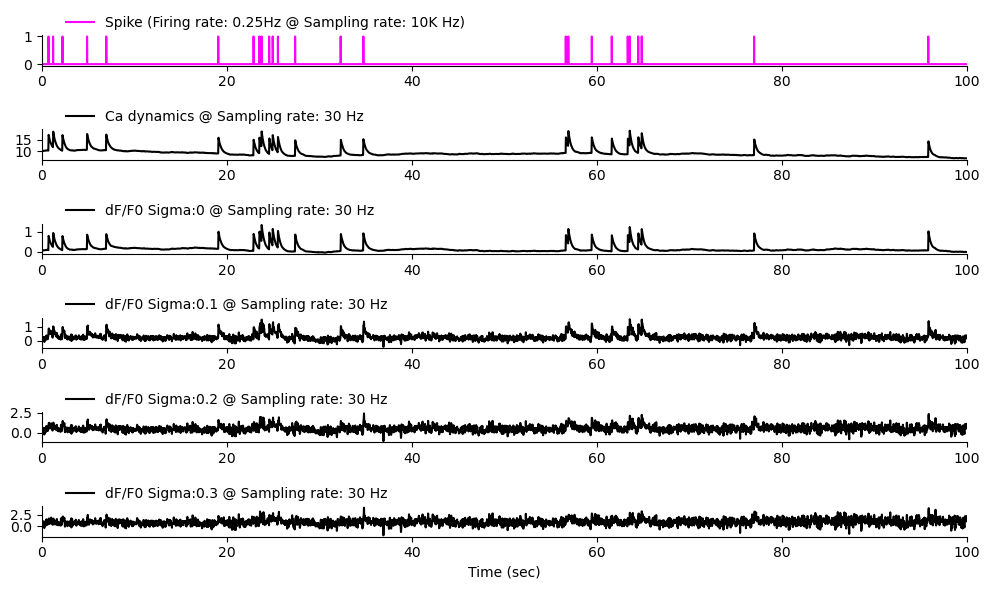

In [79]:
# Plot example neuron
Cell_id=5
plt.figure(figsize=(10,6), tight_layout=True)
plt.subplot(len(dF_F_sim_all.keys())+2,1,1)
plt.plot(t_ephys,spike_train[Cell_id], color='magenta', label='Spike (Firing rate: '+str(np.sum(spike_train[Cell_id])/total_duration)+'Hz @ Sampling rate: 10K Hz)')
plt.xlim(0,total_duration)
plt.legend(ncol=3, frameon=False, loc=(.02,1));
plt.subplot(len(dF_F_sim_all.keys())+2,1,2)
plt.xlim(0,total_duration)
plt.plot(t_imaging,Ca_dynamics_all[0][Cell_id], color='black', label='Ca dynamics'+' @ Sampling rate: ' +str(sf_imaging) +' Hz')
plt.legend(ncol=3, frameon=False, loc=(.02,1));
for i,k in enumerate(dF_F_sim_all.keys()):
    plt.subplot(len(dF_F_sim_all.keys())+2,1,i+3)
    plt.plot(t_imaging,dF_F_sim_all[k][Cell_id], color='black', label='dF/F0 Sigma:'+str(k)+' @ Sampling rate: ' +str(sf_imaging) +' Hz')
    plt.legend(ncol=3, frameon=False, loc=(.02,1));
    plt.xlim(0,total_duration)
    # plt.ylim(0,1)
plt.xlabel('Time (sec)')
sns.despine()

plt.subplots_adjust(wspace=0.4, hspace=0.6)
# plt.savefig('spike_calcium_simulation.png')

# Spike deconvolution

In [80]:
def plot_trace(t_imaging, t_ephys, dF_F, denoised, inf_spikes,true_spikes, threshold=0.2, xwindow=[0, 1000]):
    plt.figure(figsize=(10,3), tight_layout=True)
    plt.subplot(211)
    plt.plot(t_imaging, denoised, lw=1, label='denoised')
    plt.plot(t_imaging, dF_F, label='data', zorder=-12, c='y')
    plt.legend(ncol=3, frameon=False, loc=(.02,.9))
    plt.xlim(xwindow[0], xwindow[1])
    # plt.ylim(-0.5,5)
    simpleaxis(plt.gca())
    
    plt.subplot(212)
    spikes, _ = find_peaks(inf_spikes, height=threshold)
    num_inf_spikes = len(spikes)
    plt.plot(t_ephys, true_spikes+1.5, lw=1, label='true spike:'+str(len(np.where(true_spikes>0)[0])), c='black')
    plt.plot(t_imaging, inf_spikes, lw=1, label='deconvolved:'+str(num_inf_spikes), c='g')
    plt.hlines(xmin=xwindow[0], xmax=xwindow[1], y=threshold, color='red', lw=0.5, label='threhsold='+str(threshold))
    plt.ylim(0,3)
    plt.legend(ncol=3, frameon=False, loc=(.02,.9));
    simpleaxis(plt.gca())
    plt.xlim(xwindow[0], xwindow[1])
    plt.xlabel('Time (sec)')
 
    plt.subplots_adjust(wspace=0.4, hspace=0.6)

## Spike inference with OASIS AR1 model

In [81]:
def baseline_corr(F, fs, baseline='maximin', sig_baseline = 10, win_baseline=60, prctile_baseline=15):
    '''
    From suite2p
    sig_baseline:in bins, standard deviation of gaussian with which to smooth
    win_baseline:in seconds, window in which to compute max/min filters
    '''
    from scipy.ndimage import maximum_filter1d, minimum_filter1d, gaussian_filter, percentile_filter
    win = int(win_baseline * fs)
    if baseline == "maximin":
        Flow = gaussian_filter(F, [0., sig_baseline])
        Flow = minimum_filter1d(Flow, win)
        Flow = maximum_filter1d(Flow, win)
    elif baseline == "constant":
        Flow = gaussian_filter(F, [0., sig_baseline])
        Flow = np.amin(Flow)
    elif baseline == "constant_prctile":
        Flow = np.percentile(F, prctile_baseline, axis=1)
        Flow = np.expand_dims(Flow, axis=1)
    elif baseline == "percentile":
        Flow = percentile_filter(F, percentile=prctile_baseline, size=win, axes=1)
    elif baseline == "constant_median":
        Flow = np.median(F, axis=1)
        Flow = np.expand_dims(Flow, axis=1)
    Fcorr = F - Flow
    
    return Fcorr

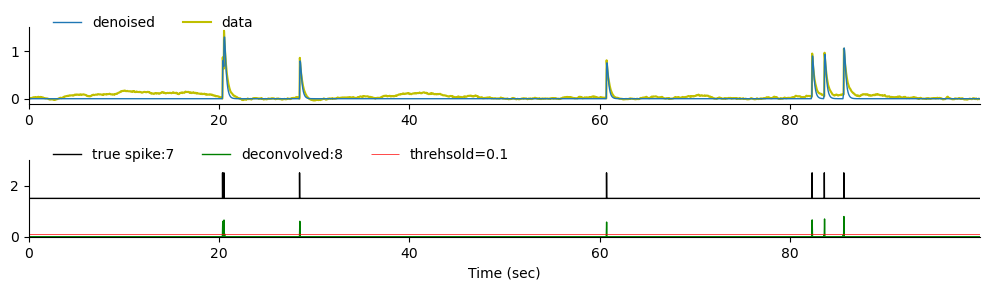

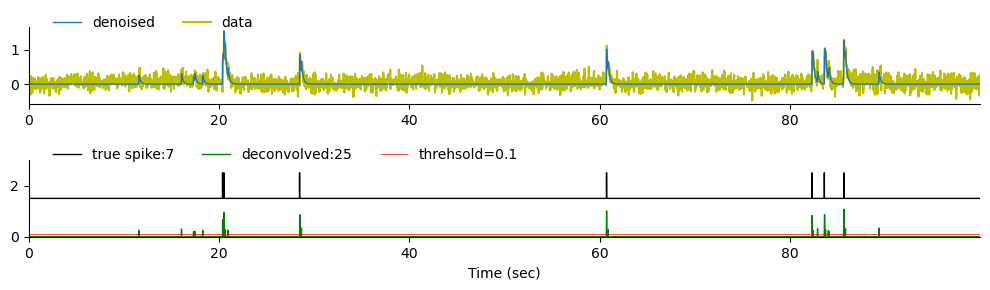

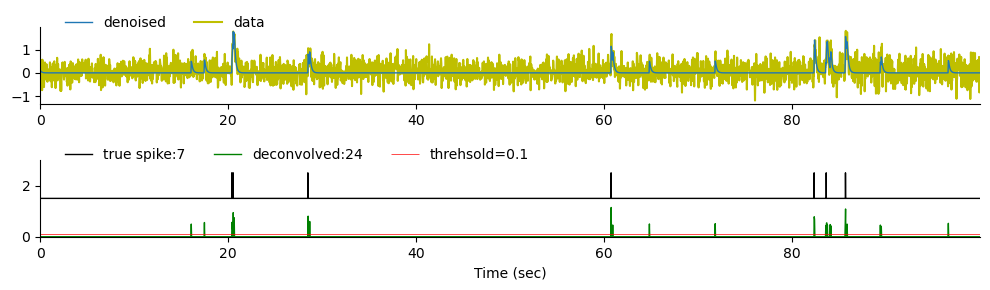

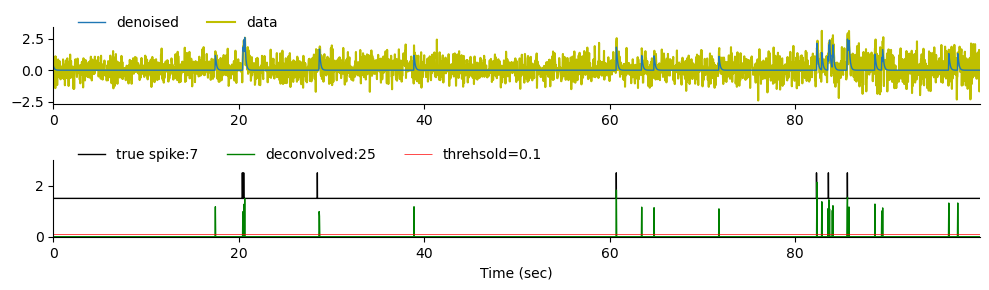

In [82]:
Cell_id=2
threshold=0.1
for k in dF_F_sim_all.keys():
    F_base_corr = baseline_corr(dF_F_sim_all[k], fs=sf_imaging, baseline='maximin', sig_baseline = 20, win_baseline= 20)
    # F_base_corr = baseline_corr(F_base_corr, fs=sf_imaging, baseline='constant_median')
    # denoised, inf_spikes = oasisAR1(F_base_corr[Cell_id], g=estimate_parameters(F_base_corr[Cell_id], p=1)[0], s_min=threshold)
    # denoised, inf_spikes = oasisAR1(F_base_corr[Cell_id], g=0.9, s_min=threshold)
    # denoised, inf_spikes, b, g, lam = deconvolve(F_base_corr[Cell_id], 
    #                          g=estimate_parameters(F_base_corr[Cell_id], p=2,fudge_factor=0.9)[0], 
    #                          penalty=0)
    denoised, inf_spikes, b, g, lam = deconvolve(F_base_corr[Cell_id], 
                             g=estimate_parameters(F_base_corr[Cell_id], p=2,fudge_factor=0.9)[0], 
                             penalty=0)
    # denoised, inf_spikes = oasisAR1(F_base_corr[Cell_id], g=0.3) 
    # inf_spikes=MinMaxScaler(feature_range=(0, 1), copy=True).fit(inf_spikes.reshape(-1,1)).transform(inf_spikes.reshape(-1,1)).reshape(-1)
    plot_trace(t_imaging, t_ephys, F_base_corr[Cell_id], denoised, inf_spikes, spike_train[Cell_id], 
               threshold=threshold, xwindow=[t_imaging.min(), t_imaging.max()])

CPU times: user 14.6 s, sys: 15 ms, total: 14.6 s
Wall time: 14.7 s


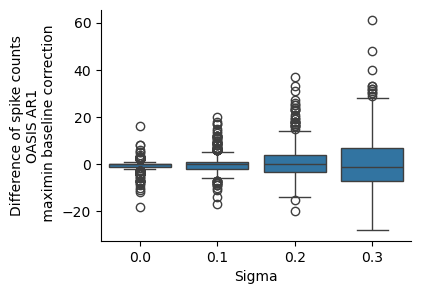

In [83]:
%%time
denoise_all={}
deconvo_all={}
for i in dF_F_sim_all.keys():
    denoise = []
    deconvo = []
    corrected_trace = baseline_corr(dF_F_sim_all[i], fs=sf_imaging, baseline='maximin', sig_baseline = 5, win_baseline=5, prctile_baseline=20)
    # corrected_trace = baseline_corr(dF_F_sim_all[i], fs=sf_imaging, baseline='constant_median')
    for v in range(Fcorr_sim_all[i].shape[0]):
        # c, s = oasisAR1(corrected_trace[v], g=0.9, s_min=threshold)
        c, s, b, g, lam = deconvolve(corrected_trace[v], 
                             g=estimate_parameters(corrected_trace[v], p=2,fudge_factor=0.9)[0], 
                             penalty=0)
        # c, s = oasisAR1(corrected_trace[v], g=estimate_parameters(corrected_trace[v], p=1)[0], s_min=threshold)
        # c, s = oasisAR1(corrected_trace[v], g=0.3)
        denoise.append(c)
        deconvo.append(s)
    denoise=np.array(denoise)
    deconvo=np.array(deconvo)
    # deconvo=MinMaxScaler(feature_range=(0, 1), copy=True).fit(deconvo.T).transform(deconvo.T).T
    denoise_all.update({i:denoise})
    deconvo_all.update({i:deconvo})

diff_spk_num_all = {}
inf_spike_train_all = {}
for k in deconvo_all.keys() :
    inf_spike_train = np.zeros(deconvo_all[k].shape)
    for i in range(inf_spike_train.shape[0]):
        inf_spikes, _ = find_peaks(deconvo_all[k][i], height=threshold)
        inf_spike_train[i][inf_spikes]=1
    diff_spk_num = (np.sum(inf_spike_train,axis=1)-np.sum(spike_train,axis=1))
    diff_spk_num_all.update({k:diff_spk_num})
    inf_spike_train_all.update({k:inf_spike_train})
data = {'Key': [],'Value': []}
for key, values in diff_spk_num_all.items():
    data['Key'].extend([key] * len(values))
    data['Value'].extend(values)

df = pd.DataFrame(data)
# Seabornを使用してViolin plotを作成
plt.figure(figsize=(4, 3), dpi=100)
sns.boxplot(x='Key', y='Value', data=df)
# plt.ylim(-5,50)
plt.xlabel('Sigma')
plt.ylabel('Difference of spike counts\nOASIS AR1\n maximin baseline correction')
sns.despine()

In [84]:
def bin_spike_trains(spike_train, bin_size_ms, sf_ephys):
    """
    Bin spike trains into larger time bins.
    
    Parameters:
    - spkTrain: 2D array of spike trains (N, Times)
    - bin_size_ms: Size of the time bin in milliseconds
    - sf_ephys: Sampling frequency of spiking activity (Hz)
    
    Returns:
    - binned_spkTrain: 2D array of binned spike trains
    """
    bin_size_samples = int(bin_size_ms * sf_ephys / 1000)  # Convert bin size to samples
    N, Times = spike_train.shape
    num_bins = Times // bin_size_samples
    
    binned_sptrain = np.zeros((N, num_bins), dtype=int)
    
    for neuron_idx in range(N):
        for bin_idx in range(num_bins):
            start = bin_idx * bin_size_samples
            end = (bin_idx + 1) * bin_size_samples
            binned_sptrain[neuron_idx, bin_idx] = np.sum(spike_train[neuron_idx, start:end])
    
    return binned_sptrain.astype('float')

In [85]:
bin_size = 1/30*1000
binned_sptrain=bin_spike_trains(spike_train, bin_size_ms=bin_size, sf_ephys=sf_ephys)

In [86]:
sigma=1# sigma for gaussian filter
sptrain_fil= gaussian_filter1d(spike_train,sigma=sigma, axis=1)
binned_sptrain_fil= gaussian_filter1d(binned_sptrain,sigma=sigma, axis=1)
deconvo_fil= gaussian_filter1d(deconvo_all[0.1],sigma=sigma, axis=1)

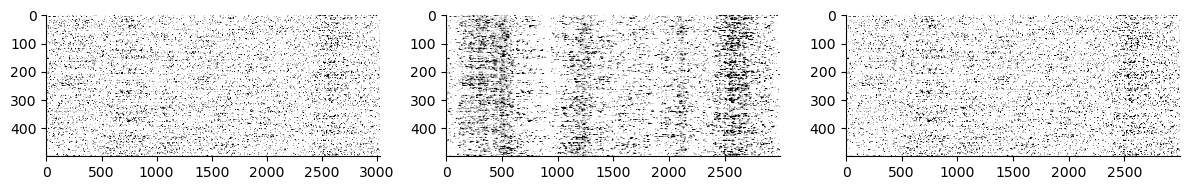

In [87]:
plt.figure(figsize=(12,2), tight_layout=True)
plt.subplot(131)
plt.imshow(stats.zscore(binned_sptrain_fil,axis=1), aspect='auto', vmin=0, vmax=1, cmap='binary')
sns.despine()

plt.subplot(132)
plt.imshow(stats.zscore(dF_F_sim_all[0.1],axis=1), aspect='auto', vmin=0, vmax=1, cmap='binary')
sns.despine()

plt.subplot(133)
plt.imshow(stats.zscore(deconvo_fil,axis=1), aspect='auto', vmin=0, vmax=1, cmap='binary')
sns.despine()

In [88]:
corr_mtx_true = np.corrcoef(binned_sptrain_fil)
# corr_mtx_inf = np.corrcoef(deconvo_all[0.1])
corr_mtx_inf = np.corrcoef(deconvo_fil)
corr_mtx_dff = np.corrcoef(dF_F_sim_all[0.1])
diff_corr_mtx = abs(corr_mtx_true-corr_mtx_inf)

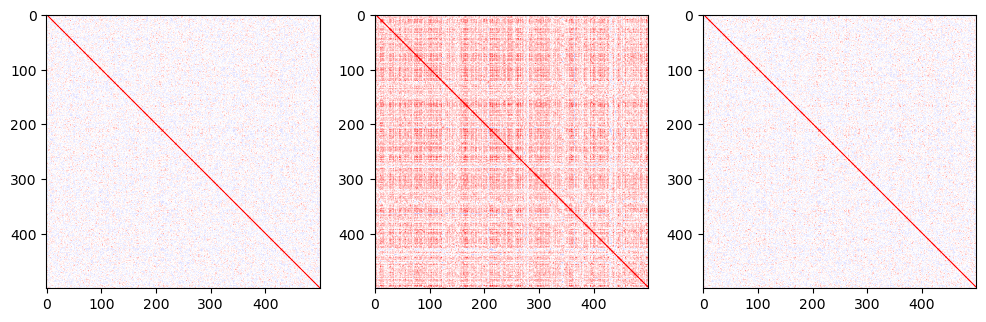

In [89]:
plt.figure(figsize=(12,4))
plt.subplot(131)
plt.imshow(corr_mtx_true, vmin=-0.2, vmax=0.2,cmap='bwr')
plt.subplot(132)
# plt.imshow(corr_mtx_inf, vmin=-0.2, vmax=0.2,cmap='bwr')
plt.imshow(corr_mtx_dff, vmin=-0.2, vmax=0.2,cmap='bwr')
plt.subplot(133)
plt.imshow(corr_mtx_inf, vmin=-0.2, vmax=0.2,cmap='bwr')
# plt.imshow(diff_corr_mtx, vmin=0, vmax=0.2,cmap='Greys')

In [90]:
corr_true = corr_mtx_true[np.triu_indices(corr_mtx_true.shape[0],k=1)]
corr_inf = corr_mtx_inf[np.triu_indices(corr_mtx_inf.shape[0],k=1)]
corr_dff = corr_mtx_dff[np.triu_indices(corr_mtx_dff.shape[0],k=1)]
diff_corr_values = diff_corr_mtx[np.triu_indices(diff_corr_mtx.shape[0], k=1)]

In [91]:
# plt.figure(figsize=(4,3))
# sns.histplot(diff_corr_values, binwidth=0.001, stat='probability', kde=False, color='gray', alpha=.5, linewidth=0.2, edgecolor='.3');
# plt.yscale('log')
# plt.xlim(0,0.2)

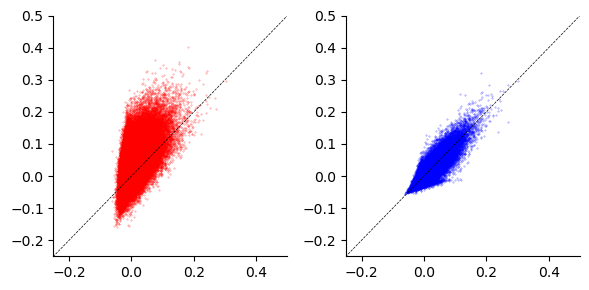

In [92]:
plt.figure(figsize=(6,3), tight_layout=True)
plt.subplot(121)
plt.scatter(corr_true,corr_dff, s=0.1, alpha=0.5, c='red')
plt.plot(np.arange(-1,2),np.arange(-1,2), lw=.5, c='k', linestyle='dashed')
plt.xlim(-0.25,0.5)
plt.ylim(-0.25,0.5)
plt.subplot(122)
plt.scatter(corr_true,corr_inf, s=0.1, alpha=0.5, c='blue')
plt.plot(np.arange(-1,2),np.arange(-1,2), lw=.5, c='k', linestyle='dashed')
plt.xlim(-0.25,0.5)
plt.ylim(-0.25,0.5)
sns.despine()

In [93]:
def partialcorr(x, z):
    '''
    x: signal time x neurons
    z: control variable time x n
    '''
    
    from scipy.stats import rankdata

    x = x.T
    z = z.reshape(1,-1).T
    n = x.shape[0]
    d = x.shape[1]
    sizeOut = np.array([d, d])

    dz = np.linalg.matrix_rank(z)

    z1 = np.hstack([np.ones([n,1]), z])
    resid = x - z1 @ np.linalg.lstsq(z1, x, rcond=None)[0]

    tol = max(n, dz) * np.finfo(x.dtype).eps * np.sqrt(np.sum(np.abs(x) ** 2, axis=0))
    resid[:,np.sqrt(np.sum(np.abs(resid)**2,axis=0)) < tol] = 0

    pcorr_mtx = np.corrcoef(resid.T)
    np.fill_diagonal(pcorr_mtx,0)
    return pcorr_mtx

In [94]:
def partialcorr_2(x):
    cov_matrix = np.cov(x)
    precision_matrix = np.linalg.inv(cov_matrix)

    # Calculate partial correlation
    d = np.sqrt(np.diag(precision_matrix))
    pcorr_mtx = -precision_matrix / np.outer(d, d)
    # set diagonal term 0
    np.fill_diagonal(pcorr_mtx, 0)
    
    return pcorr_mtx

In [95]:
pcorr_mtx = partialcorr(binned_sptrain_fil, np.mean(binned_sptrain_fil,axis=0))
pcorr_mtx_dff = partialcorr(dF_F_sim_all[0.1], np.mean(dF_F_sim_all[0.1],axis=0))
pcorr_mtx_inf = partialcorr(deconvo_fil, np.mean(deconvo_fil,axis=0))

# pcorr_mtx = partialcorr_2(binned_sptrain_fil)
# pcorr_mtx_dff = partialcorr_2(dF_F_sim_all[0.1])
# pcorr_mtx_inf = partialcorr_2(deconvo_fil)

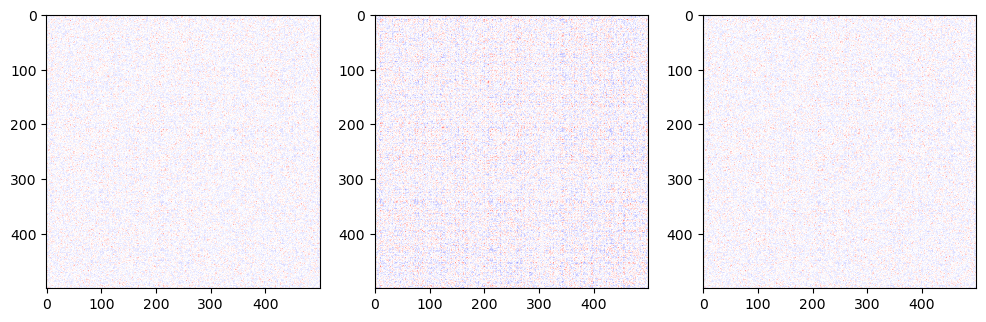

In [96]:
plt.figure(figsize=(12,4))
plt.subplot(131)
plt.imshow(pcorr_mtx, vmin=-0.2, vmax=0.2,cmap='bwr')
plt.subplot(132)
# plt.imshow(corr_mtx_inf, vmin=-0.2, vmax=0.2,cmap='bwr')
plt.imshow(pcorr_mtx_dff, vmin=-0.2, vmax=0.2,cmap='bwr')
plt.subplot(133)
plt.imshow(pcorr_mtx_inf, vmin=-0.2, vmax=0.2,cmap='bwr')
# plt.imshow(diff_corr_mtx, vmin=0, vmax=0.2,cmap='Greys')

In [97]:
pcorr_true = pcorr_mtx[np.triu_indices(pcorr_mtx.shape[0],k=1)]
pcorr_dff = pcorr_mtx_dff[np.triu_indices(pcorr_mtx_dff.shape[0],k=1)]
pcorr_inf = pcorr_mtx_inf[np.triu_indices(pcorr_mtx_inf.shape[0],k=1)]

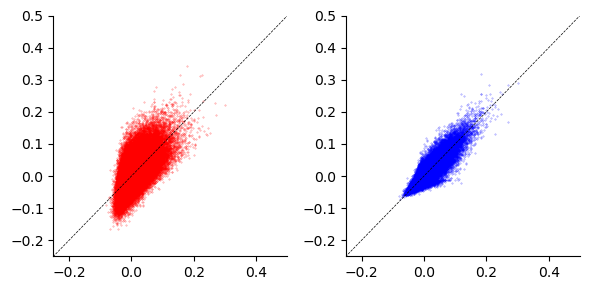

In [98]:
plt.figure(figsize=(6,3), tight_layout=True)
plt.subplot(121)
plt.scatter(pcorr_true,pcorr_dff, s=0.1, alpha=0.5, c='red')
plt.plot(np.arange(-1,2),np.arange(-1,2), lw=.5, c='k', linestyle='dashed')
plt.xlim(-0.25,0.5)
plt.ylim(-0.25,0.5)
plt.subplot(122)
plt.scatter(pcorr_true,pcorr_inf, s=0.1, alpha=0.5, c='blue')
plt.plot(np.arange(-1,2),np.arange(-1,2), lw=.5, c='k', linestyle='dashed')
plt.xlim(-0.25,0.5)
plt.ylim(-0.25,0.5)
sns.despine()

In [99]:
from sklearn.decomposition import FactorAnalysis


# 共分散行列を計算
C = np.cov(binned_sptrain_fil.T, rowvar=False)

# 因子分析を用いて低ランク近似を計算
fa = FactorAnalysis(n_components=5)  # 低ランクの次元数を設定
fa.fit(binned_sptrain_fil.T)

# 低ランク行列 L を取得
L = fa.components_.T @ fa.components_

# 対角行列 D を計算
D = np.diag(C - L)

# 低ランク成分と対角成分の和としての推定共分散行列
C_approx = L + np.diag(D)

<Axes: >

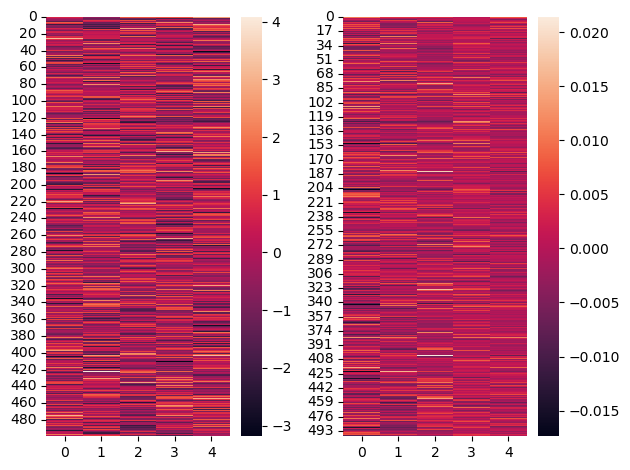

In [100]:
plt.figure(tight_layout=True)
plt.subplot(121)
sns.heatmap(W)
plt.subplot(122)
sns.heatmap(fa.components_.T)

In [167]:
cellID = np.random.choice(np.arange(0,spike_train.shape[0]), size=6, replace=False)
cellID

array([324, 437,  43, 343, 358, 279])

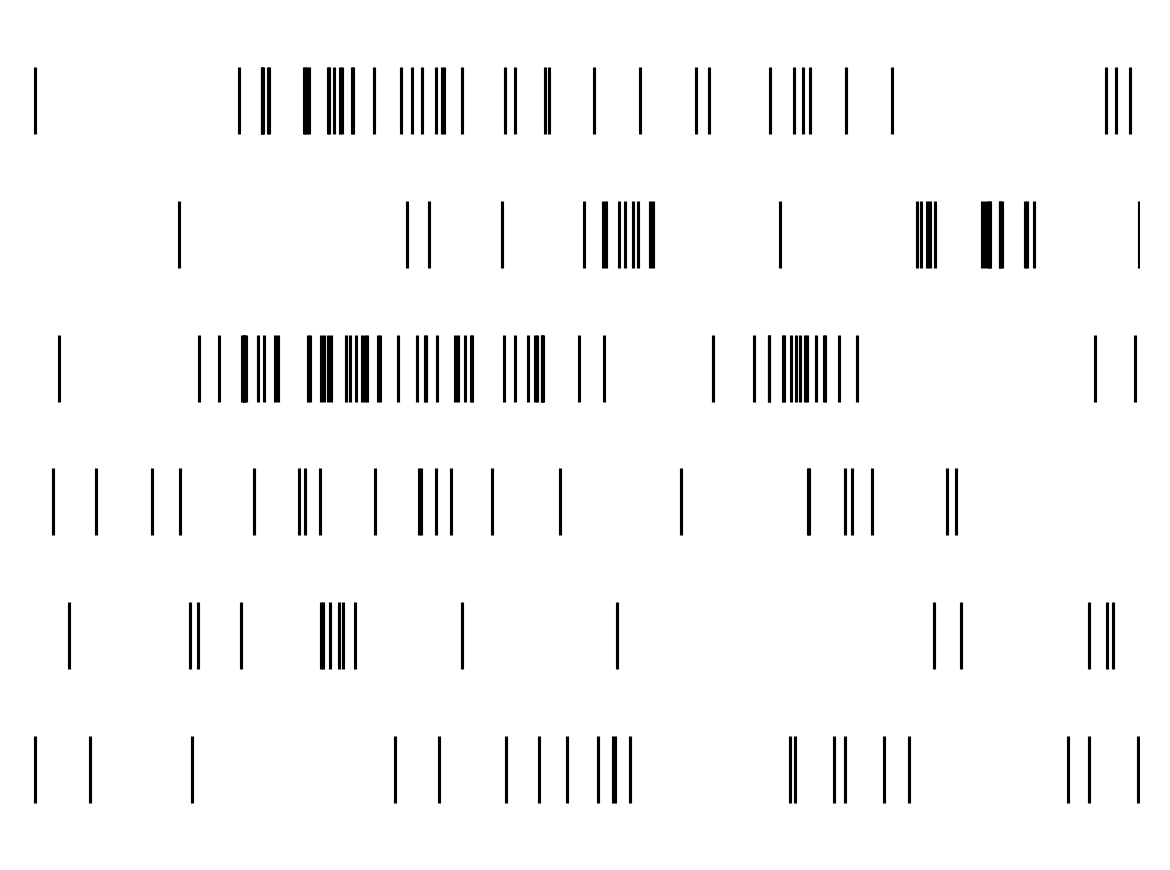

In [169]:
plt.figure(figsize=(4,3), tight_layout=True, dpi=300)
for i, v in enumerate(cellID):
    plt.vlines(x=np.where(spike_train[v]==1)[0]/sf_ephys, ymin=i+0.5, ymax=i+1, lw=0.75, color='black')
plt.xlim(0, total_duration)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['bottom'].set_visible(False)
plt.gca().spines['left'].set_visible(False)
plt.tick_params(labelbottom=False, labelleft=False, labelright=False, labeltop=False, bottom=False, left=False, right=False, top=False)
plt.savefig('raster_plot.svg')

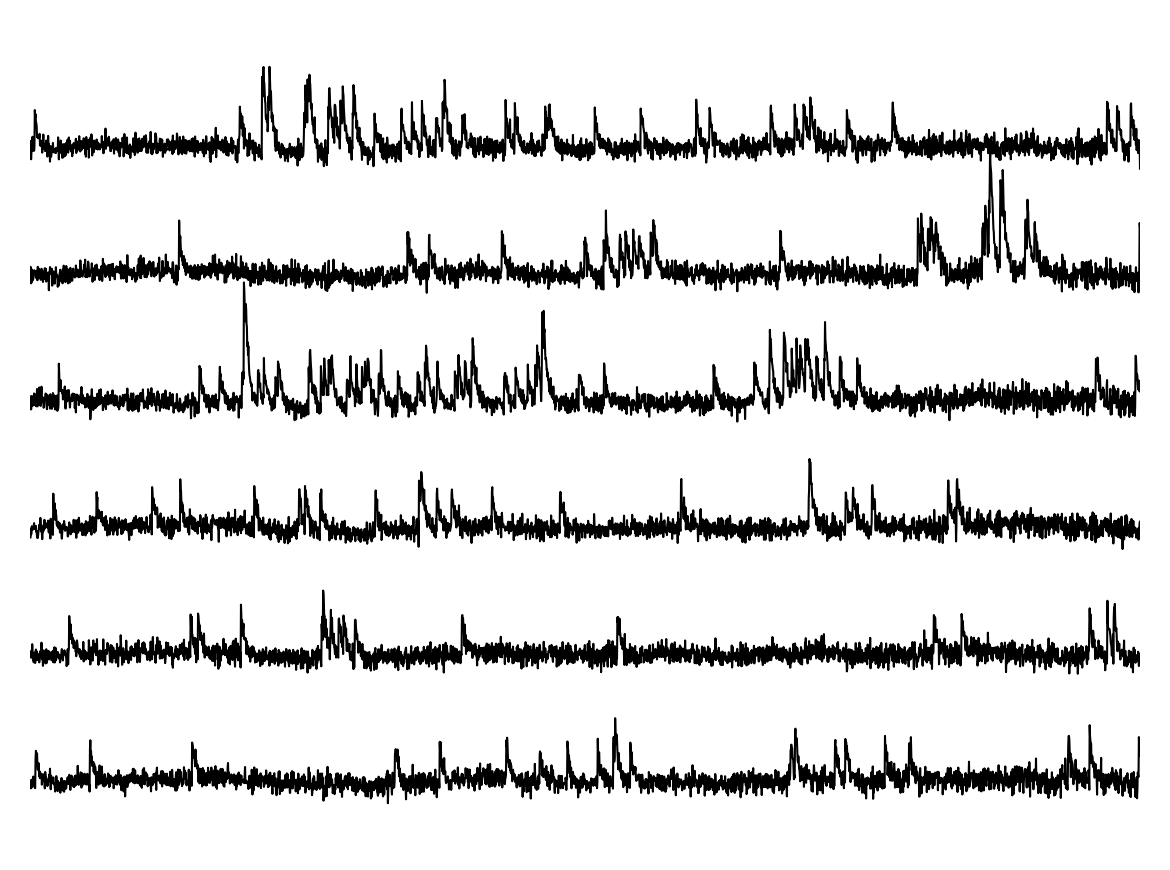

In [181]:
plt.figure(figsize=(4,3), tight_layout=True, dpi=300)
for i, v in enumerate(cellID):
    plt.plot(t_imaging,dF_F_sim_all[0.1][v]+3*i, color='black', lw=0.5)
plt.xlim(0, max(t_imaging))
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['bottom'].set_visible(False)
plt.gca().spines['left'].set_visible(False)
plt.tick_params(labelbottom=False, labelleft=False, labelright=False, labeltop=False, bottom=False, left=False, right=False, top=False)
plt.savefig('dF_F_plot.svg')

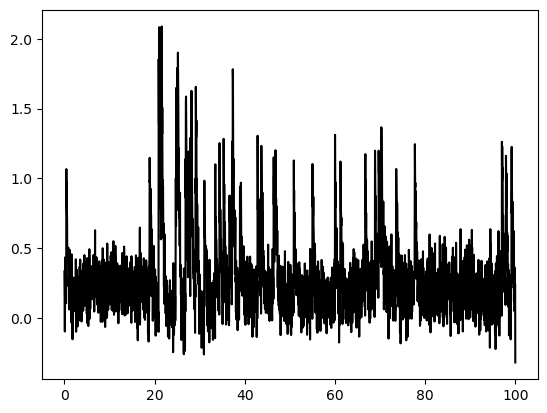

In [174]:
plt.plot(t_imaging,dF_F_sim_all[0.1][v], color='black', label='Ca dynamics'+' @ Sampling rate: ' +str(sf_imaging) +' Hz')

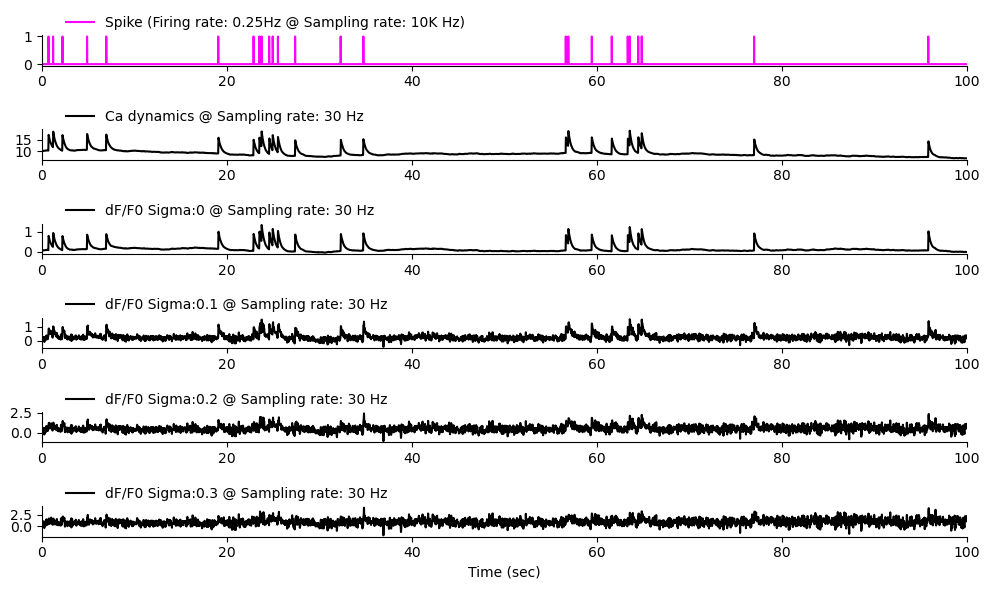

In [101]:
# Plot example neuron
Cell_id=5
plt.figure(figsize=(10,6), tight_layout=True)
plt.subplot(len(dF_F_sim_all.keys())+2,1,1)
plt.plot(t_ephys,spike_train[Cell_id], color='magenta', label='Spike (Firing rate: '+str(np.sum(spike_train[Cell_id])/total_duration)+'Hz @ Sampling rate: 10K Hz)')
plt.xlim(0,total_duration)
plt.legend(ncol=3, frameon=False, loc=(.02,1));
plt.subplot(len(dF_F_sim_all.keys())+2,1,2)
plt.xlim(0,total_duration)
plt.plot(t_imaging,Ca_dynamics_all[0][Cell_id], color='black', label='Ca dynamics'+' @ Sampling rate: ' +str(sf_imaging) +' Hz')
plt.legend(ncol=3, frameon=False, loc=(.02,1));
for i,k in enumerate(dF_F_sim_all.keys()):
    plt.subplot(len(dF_F_sim_all.keys())+2,1,i+3)
    plt.plot(t_imaging,dF_F_sim_all[k][Cell_id], color='black', label='dF/F0 Sigma:'+str(k)+' @ Sampling rate: ' +str(sf_imaging) +' Hz')
    plt.legend(ncol=3, frameon=False, loc=(.02,1));
    plt.xlim(0,total_duration)
    # plt.ylim(0,1)
plt.xlabel('Time (sec)')
sns.despine()

plt.subplots_adjust(wspace=0.4, hspace=0.6)
# plt.savefig('spike_calcium_simulation.png')